**1. (18 points) During the month of September, we see the following number of items delivered via USPS at a particular location: 6, 7, 6, 7, 7, 6, 11, 4, 8, 6, 6, 12, 2, 8, 12, 5, 7, 8, 6, 11, 6, 8, 9, 11, 5, 9, 8, 9, 8, 12**

**(a) We’d like to organize this data into 3 groups, corresponding to high, medium, and low delivery days. Use smoothing by bin means to accomplish this, using a bin depth of 10. Illustrate your steps.**

If you put all the numbers in order and spit it into 3 groups of 10, you get: low: [2,4,5,5,6,6,6,6,6,6], medium: [6,7,7,7,7,8,8,8,8,8], high: [8,9,9,9,11,11,11,12,12,12], when u find the mean of these sets you get low: 5.2, medium: 7.4, and high: 10.4. 

Now the bins are as follows:

Low delivery days: [5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2]

Medium delivery days: [7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4]

High delivery days: [10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4]

**(b) Repeat the steps in part (a), this time using smoothing by bin medians into 3 bins of equal width**

To find the depth of each bin: (12-2)/3 = 3.3
low:[2,4,5,5], medium:[6,6,6,6,6,6,6,7,7,7,78,8,8,8,8,8], high:[9,9,9,11,11,11,12,12,12]. 

The medians of each of these are as follows: 
low: 4.5, medium: 7, high: 11

Now the bins are:

Low delivery days: [4.5, 4.5, 4.5, 4.5]

Medium delivery days: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]

High delivery days: [11, 11, 11, 11, 11, 11, 11, 11, 11]

**(c) Comment on which smoothing method, if any, you would prefer to use for the given data, giving reasons as to why.**

I would prefer to use smoothing by bin medians becasue i feel like the result represents the data better than smoothing by means. I feel this way because the bins have a bigger range, which helps capture more of the data.

**(d) If we apply min-max normalization to the numbers of mailed items onto the range [0.0, 1.0], what would be the transformed value of 5?**

(5-2)/(12-2) = 3/10 = 0.3

The transformed value of 5 would be 0.3.

**(e) If we apply z-score normalization (standardization) to the numbers of mailed items, what is the transformed value of 5?**

All the numbers added together = 230

230/30 = 7.67 = mean

standard deviation = 2.43

z-score: (5-7.67)/2.43 = -1.1

The transformed value of 5 would be -1.1

**(f) Comment on which normalization method, if any, you would prefer to use for the given data, giving reasons as to why.**

I would prefer to use z-score normalization because I can visualize more and get more from it. The z-score normalization tells me that 5 is a little over 1 standard deviation bellow the mean. Where the min-max normalization only tells me 5 is 30% of the way from the minimum to the maximum.

**2.**

**(a) Use the sm.OLS() function to perform a simple linear regression with bikers as the re-sponse and temp as the predictor. Use the summarize() function to print the results.**

In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP.models import summarize

# read in csvs
Bike_day = pd.read_csv('../data/bike+sharing+dataset/day.csv')
Bike_hour = pd.read_csv('../data/bike+sharing+dataset/hour.csv')

# bikers = response, temp = predictor
X = Bike_day[['temp']].copy()     # predictor
y = Bike_day['cnt']               # response

# add intercept column
X['intercept'] = np.ones(Bike_day.shape[0])

# fit OLS model
model = sm.OLS(y, X).fit()


# summarize results
summarize(model)
#print(model.summary())

,coef,std err,t,P>|t|
temp,6640.7100,305.188,21.759,0.0
intercept,1214.6421,161.164,7.537,0.0


**(b) Explain why we can deduce that there is a significant association between the predictor and the response.**

The coeficient for temperature is 6640, which means for each unit increase in temperature the expected # of bikers increased by about 6640 on average. The p-value being 0 allows us the reject the null hypothesis which means it is very unlikely this result is due to random chance.

**(c) How strong is the relationship between the predictor and the response? Use the R2 statistic to support your answer.**

In [24]:
print("R-squared:", model.rsquared)

R-squared: 0.3937487313729242


The relationship between the predictor and the response is strong given it is only one variable. The R-squared value is 0.39 which means around 39% of the variation in bike usage can be explained by temperature. For a single variable, this is a lot.

**(d) Is the relationship between the predictor and the response positive or negative? How can you tell?**

The relationship between the predictor and the response is positive. This can be seen by the fact that the slope coefficient for temperature is positive.

**(e) According to this model, what is the predicted number of bikers on a day that averages the minimum temp?**

In [27]:
print(min(Bike_day['temp']))

0.0591304


interecept coefficient = 1214.64
temp coefficient = 6640.71
minimum avg. temp: 0.0591

1214.64 + (6640.71 * (0.05913)) = 1,607

The predicted number of bikers on a day that averages the minimum temp is 1,607.

**(f) Why might it be inappropriate to use this model to estimate the number of bikers on this day?**

It may be inappropriate to use this model to estimate the number of bikers at the minimum temperature because the model is based on a linear trend across the observed range of temperatures, and very cold days are likely underrepresented in the data. This model also doesn’t account for other factors that affect biking on very cold days, like snow or ice. This makes the prediction less reliable at extreme temperatures.

**(g) Plot the response and the predictor in a new set of axes ax. Use the ax.axline() method or the abline() function defined in the lab to display the least squares regression line.**

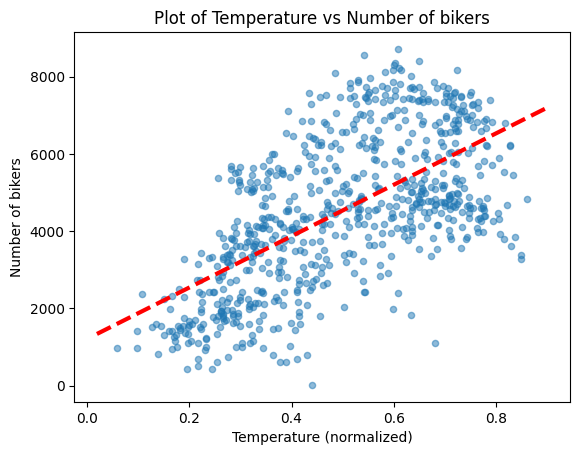

In [ ]:
import matplotlib.pyplot as plt

def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

# scatterplot of temp vs cnt
ax = Bike_day.plot.scatter('temp', 'cnt', alpha=0.5)
ax.set_title("Plot of Temperature vs Number of bikers")
ax.set_xlabel("Temperature (normalized)")
ax.set_ylabel("Number of bikers")

# regression line
abline(ax,
       model.params['const'],   # intercept
       model.params['temp'],    # slope
       'r--',
       linewidth=3)

**(h) Produce a residual plot which compares the observed bikers values to the predicted ones**

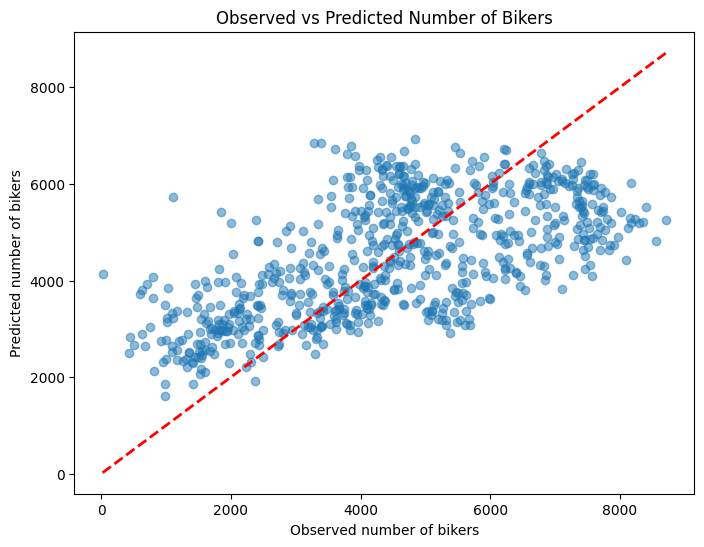

In [ ]:
# predicted values
X = sm.add_constant(Bike_day['temp'])
y_pred = model.predict(X)

# observed values
y_obs = Bike_day['cnt']

# plot observed vs predicted
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(y_obs, y_pred, alpha=0.5)

# add y=x line for reference
lims = [min(y_obs.min(), y_pred.min()), max(y_obs.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2)

# add axis titles
ax.set_title("Observed vs Predicted Number of Bikers")
ax.set_xlabel("Observed number of bikers")
ax.set_ylabel("Predicted number of bikers")

plt.show()

**3.**

**(a) Compute the matrix of correlations between the numeric variables (including hr) using the corr() method.**

In [ ]:
corr_matrix = Bike_hour.corr(numeric_only=True)
print(corr_matrix)

             instant    season        yr      mnth        hr   holiday  \
instant     1.000000  0.404046  0.866014  0.489164 -0.004775  0.014723   
season      0.404046  1.000000 -0.010742  0.830386 -0.006117 -0.009585   
yr          0.866014 -0.010742  1.000000 -0.010473 -0.003867  0.006692   
mnth        0.489164  0.830386 -0.010473  1.000000 -0.005772  0.018430   
hr         -0.004775 -0.006117 -0.003867 -0.005772  1.000000  0.000479   
holiday     0.014723 -0.009585  0.006692  0.018430  0.000479  1.000000   
weekday     0.001357 -0.002335 -0.004485  0.010400 -0.003498 -0.102088   
workingday -0.003416  0.013743 -0.002196 -0.003477  0.002285 -0.252471   
weathersit -0.014198 -0.014524 -0.019157  0.005400 -0.020203 -0.017036   
temp        0.136178  0.312025  0.040913  0.201691  0.137603 -0.027340   
atemp       0.137615  0.319380  0.039222  0.208096  0.133750 -0.030973   
hum         0.009577  0.150625 -0.083546  0.164411 -0.276498 -0.010588   
windspeed  -0.074505 -0.149773 -0.0087

**(b) Provide a scatterplot of hr versus bikers. Note that there is a lot of variation and the effect appears to be nonlinear.**

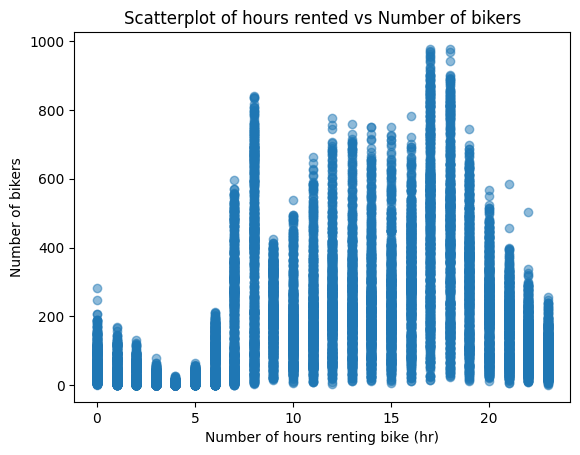

In [ ]:
# create plot
plt.scatter(Bike_hour['hr'], Bike_hour['cnt'], alpha=0.5)

# add labels
plt.xlabel("Number of hours renting bike (hr)")
plt.ylabel("Number of bikers")
plt.title("Scatterplot of hours rented vs Number of bikers")

plt.show()

**(c) Use the sm.OLS() function to perform a multiple linear regression with bikers as the response and only hr and an intercept as predictors. Use the summarize() function to print the results, and calculate the MSE for this model.**

In [ ]:
# variable and intercept
X = sm.add_constant(Bike_hour['hr'])
y = Bike_hour['cnt']

model1 = sm.OLS(y, X).fit()
print(model1.summary())

# MSE
mse1 = ((model1.resid)**2).mean()
print("MSE model1:", mse1)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     3195.
Date:                Wed, 01 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:49:45   Log-Likelihood:            -1.1357e+05
No. Observations:               17379   AIC:                         2.272e+05
Df Residuals:                   17377   BIC:                         2.272e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         70.0952      2.462     28.475      0.0

**(d) Based on the scatterplot in (b), it seems possible that a degree 2 effect may improve the fit for the hr variable. Refit the model using hr, hr2, and the intercept as variables. Again provide the model results and MSE.**

In [ ]:
# create squared term
Bike_hour['hr2'] = Bike_hour['hr']**2

X = sm.add_constant(Bike_hour[['hr','hr2']])
model2 = sm.OLS(y, X).fit()
print(model2.summary())

mse2 = ((model2.resid)**2).mean()
print("MSE model2:", mse2)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     3677.
Date:                Wed, 01 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:50:16   Log-Likelihood:            -1.1197e+05
No. Observations:               17379   AIC:                         2.240e+05
Df Residuals:                   17376   BIC:                         2.240e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -65.1308      3.201    -20.349      0.0

**(e) We also see in the scatterplot in (b) that, on average, more bikes are used during commuting hours. This suggests a possible interaction between hr and workingday. Refit the model using hr, hr2, workingday, hr×workingday, and the intercept as variables. Again provide the model results and MSE.**

In [ ]:
# add interaction term
Bike_hour['hr_workday'] = Bike_hour['hr'] * Bike_hour['workingday']

X = sm.add_constant(Bike_hour[['hr','hr2','workingday','hr_workday']])
model3 = sm.OLS(y, X).fit()
print(model3.summary())

mse3 = ((model3.resid)**2).mean()
print("MSE model3:", mse3)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     1854.
Date:                Wed, 01 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:50:53   Log-Likelihood:            -1.1195e+05
No. Observations:               17379   AIC:                         2.239e+05
Df Residuals:                   17374   BIC:                         2.240e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -59.6390      4.579    -13.024      0.0

**(f) In question (2), we saw that temp was predictive, so let’s add that to our model. Refit the model using hr, hr2, workingday, hr×workingday, temp, and the intercept as variables. Again provide the model results and MSE.**

In [ ]:
# add temp
X = sm.add_constant(Bike_hour[['hr','hr2','workingday','hr_workday','temp']])
model4 = sm.OLS(y, X).fit()
print(model4.summary())

mse4 = ((model4.resid)**2).mean()
print("MSE model4:", mse4)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     2311.
Date:                Wed, 01 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:51:12   Log-Likelihood:            -1.1061e+05
No. Observations:               17379   AIC:                         2.212e+05
Df Residuals:                   17373   BIC:                         2.213e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -180.4894      4.796    -37.633      0.0

**(g) Noticing the improvement to MSE with each additional variable, you may decide to include many more predictors in your next iteration. What do you expect would happen to the MSE on the training data?**

Training MSE will always decrease or stay the same because OLS fits exactly by minimizing residuals.

**(h) Suppose you are given unseen holdout data from 2013 to use for testing. Which of these models would you expect to have the best performance? Why?**

I would expect Model 4 to have the best performance because it doesnt have too many variables but captures the nonlinear pattern and temperature which are both key elements of the data.